# Time domain examples

Example code which integrates the equations of motion governing linearized radial perturbations of perfect, Eckart and BDNK fluid stars in the time domain. We additionally include code which integrates perfect and BDNK fluid stars in the Cowling approximation.

In [1]:
include("params.jl");

In [2]:
h1 = h_save;
h2 = h_save / 2.0;
h3 = h_save / 4.0;

## Perfect fluid cowling

In [3]:
cowling = true;

In [4]:
@time time_integrate(PF_star, h1, cowling; print_progress = true);
@time time_integrate(PF_star, h2, cowling; print_progress = true);
@time time_integrate(PF_star, h3, cowling; print_progress = true);

Integrating the perfect fluid cowling equations of motion in time...
File ./Results/Data/Cowling_time_domain_κ_700_n_0.8_εc_2.23e-03_ptol_7.55e-07_η_0.0e+00_ζ_0.0e+00_τε_0.0e+00_τP_0.0e+00_τQ_0.0e+00_L_1.0_KO_0.0_CFL_0.1_T_0.05_h_4.0e-02.h5 already exists and will be overwritten.
  2.392976 seconds (34.06 M allocations: 715.151 MiB, 7.25% gc time, 128.42% compilation time: 7% of which was recompilation)
Integrating the perfect fluid cowling equations of motion in time...
File ./Results/Data/Cowling_time_domain_κ_700_n_0.8_εc_2.23e-03_ptol_7.55e-07_η_0.0e+00_ζ_0.0e+00_τε_0.0e+00_τP_0.0e+00_τQ_0.0e+00_L_1.0_KO_0.0_CFL_0.1_T_0.05_h_2.0e-02.h5 already exists and will be overwritten.
  6.243540 seconds (113.11 M allocations: 2.152 GiB, 8.78% gc time, 94.01% compilation time)
Integrating the perfect fluid cowling equations of motion in time...
File ./Results/Data/Cowling_time_domain_κ_700_n_0.8_εc_2.23e-03_ptol_7.55e-07_η_0.0e+00_ζ_0.0e+00_τε_0.0e+00_τP_0.0e+00_τQ_0.0e+00_L_1.0_KO_0.0_CFL_0.

Excessive output truncated after 524291 bytes.

Load solution and print keys

In [5]:
sol1 = load_td_solution(PF_star, h1, cowling);
keys(sol1["solution"])

11-element Vector{String}:
 "IR"
 "cs"
 "cs_prime"
 "m"
 "p"
 "r"
 "t"
 "xi"
 "xi_dot"
 "ε"
 "ν"

In [6]:
close(sol1)

Plot solution at fixed time

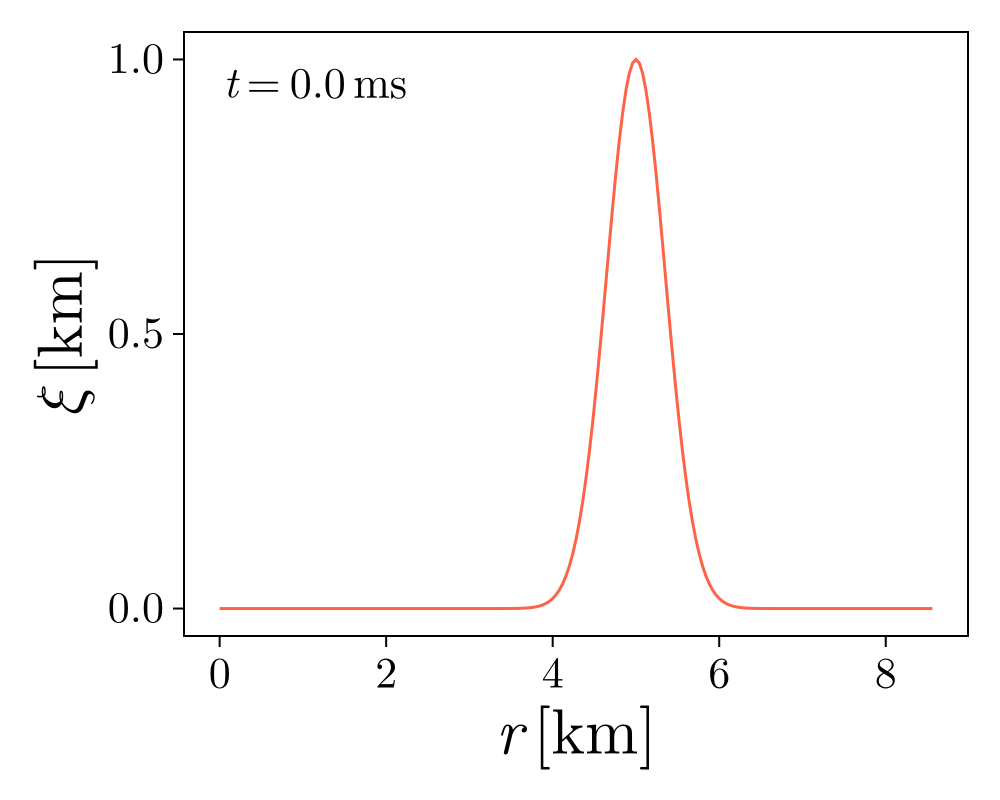

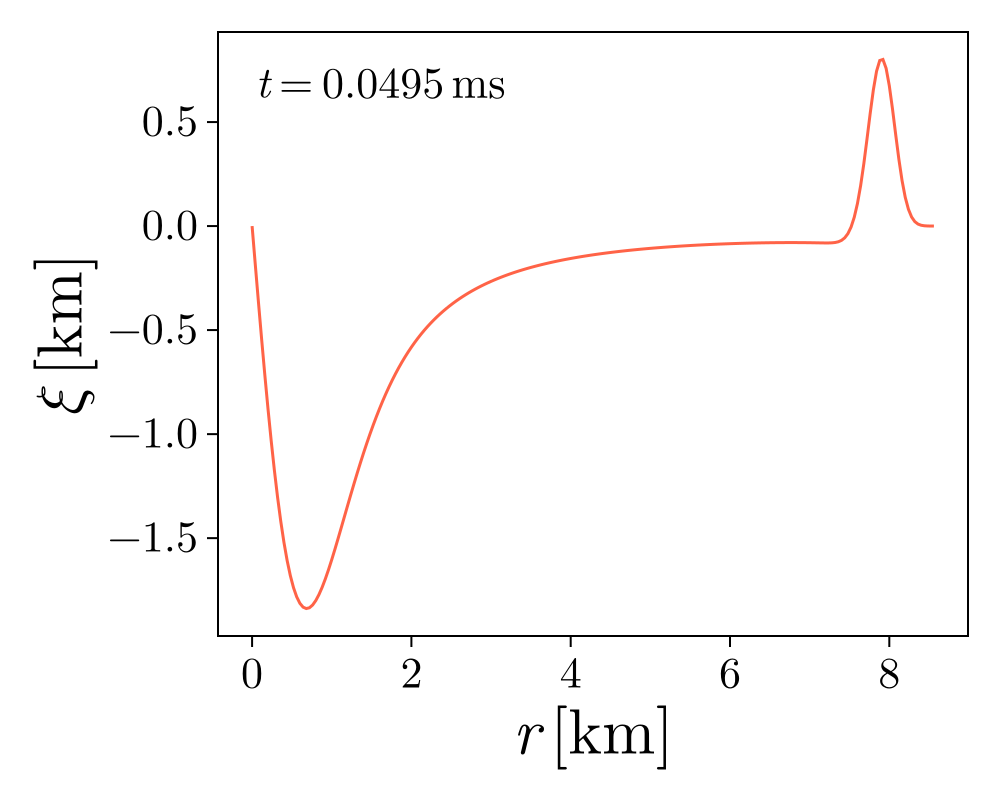

In [7]:
time = 0.05;
var = "xi";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";

plot_td_var(
    PF_star, h3, var, 0.0, cowling;
    desample_factor=1,
    annotate_time=true,
    xlabel = xlabel,
    ylabel = ylabel
);

plot_td_var(
    PF_star, h3, var, time, cowling;
    desample_factor=1,
    annotate_time=true,
    xlabel = xlabel,
    ylabel = ylabel
);

To monitor convergence, plot one-norm of independent residual for three different resolutions

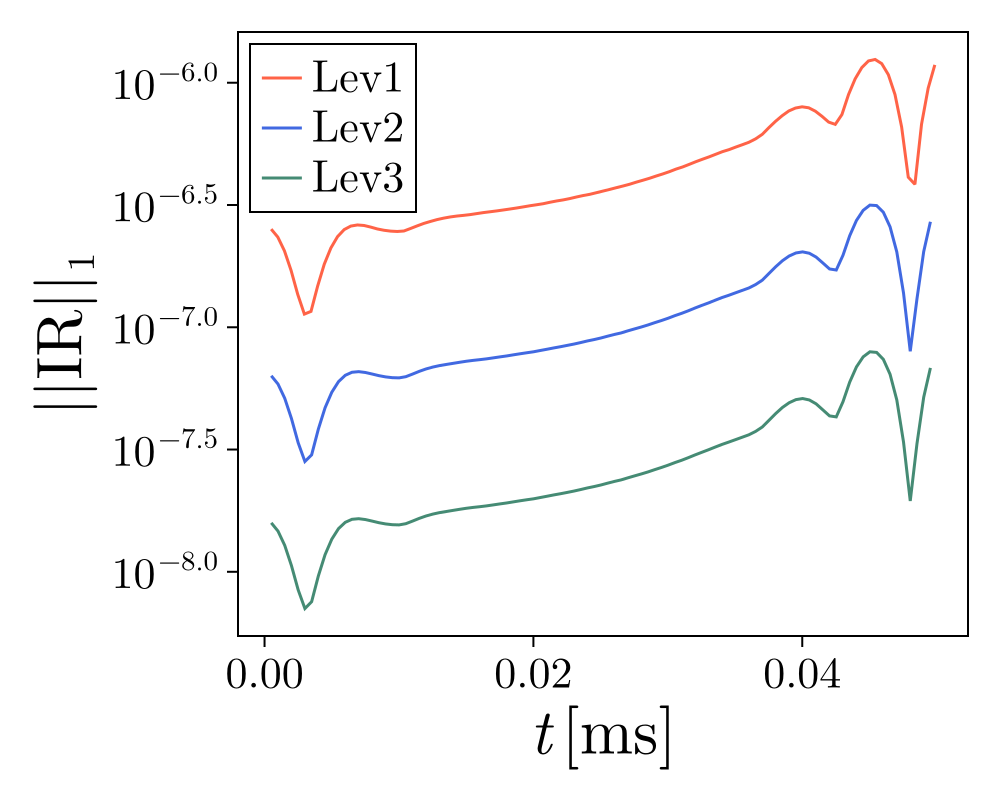

In [8]:
resolutions = [h1, h2, h3];
var = "IR";
xlabel = L"t\,[\mathrm{ms}]";
ylabel = L"||\mathrm{IR}||_1";
labels = ["Lev1", "Lev2", "Lev3"];
legend = true;
position = :lt;
plot_IR_one_norms(
    PF_star, resolutions, var, time, cowling;
    desample_factor=1,
    xlabel = xlabel,
    ylabel = ylabel,
    yscale = log10,
    labels = labels,
    legend = legend,
    position = position
);

Make basic animation of time evolution (saved to star.fig_path)

In [9]:
var = "xi";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
animate_td_var(
    PF_star, h3, var, cowling;
    desample_factor=1,
    stop_time=PF_star.T, # stop time of animation in ms
    animation_length=10.0, # length of animation in seconds
    framerate=10, # frames per second
    xlabel = xlabel,
    ylabel = ylabel,
    fix_ylims = false, # whether to fix y-limits of plot
)

"./Results/Figures/Cowling_time_domain_κ_700_n_0.8_εc_2.23e-03_ptol_7.55e-07_η_0.0e+00_ζ_0.0e+00_τε_0.0e+00_τP_0.0e+00_τQ_0.0e+00_L_1.0_KO_0.0_CFL_0.1_T_0.05_h_1.0e-02_xi.mp4"

## Perfect fluid

In [10]:
cowling = false;

In [11]:
@time time_integrate(PF_star, h1, cowling; print_progress = true);
@time time_integrate(PF_star, h2, cowling; print_progress = true);
@time time_integrate(PF_star, h3, cowling; print_progress = true);

Load solution and print keys

In [12]:
sol1 = load_td_solution(PF_star, h1, cowling);
keys(sol1["solution"])

11-element Vector{String}:
 "IR"
 "cs"
 "cs_prime"
 "m"
 "p"
 "r"
 "t"
 "xi"
 "xi_dot"
 "ε"
 "ν"

In [13]:
close(sol1)

Plot solution at fixed time

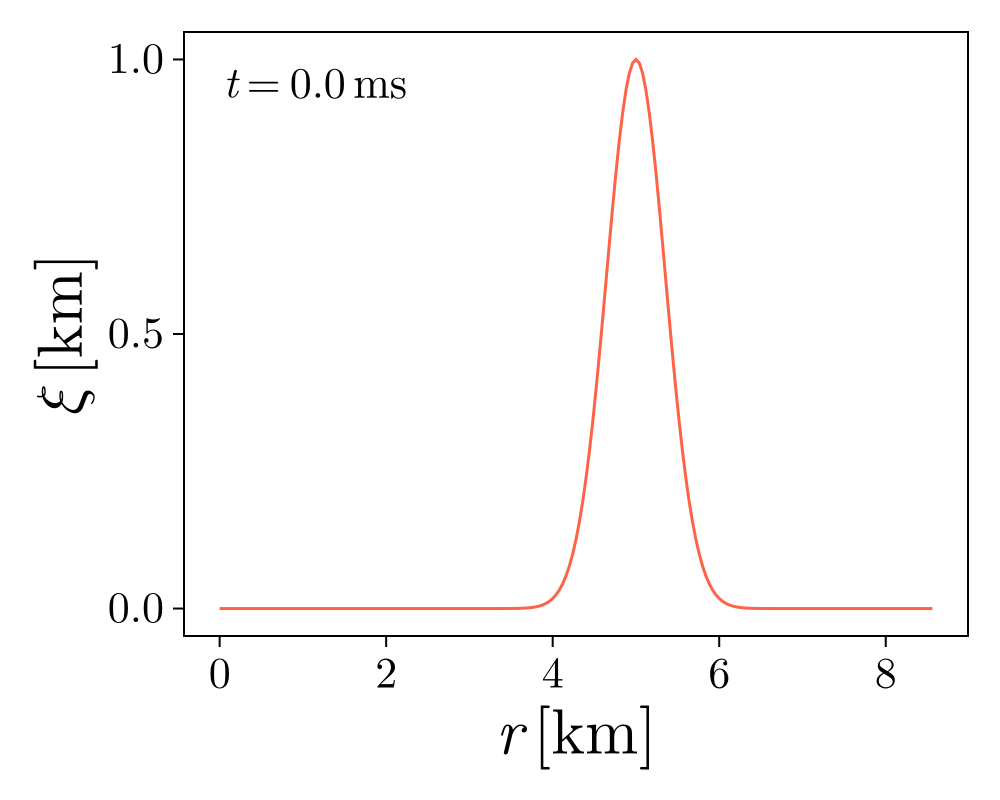

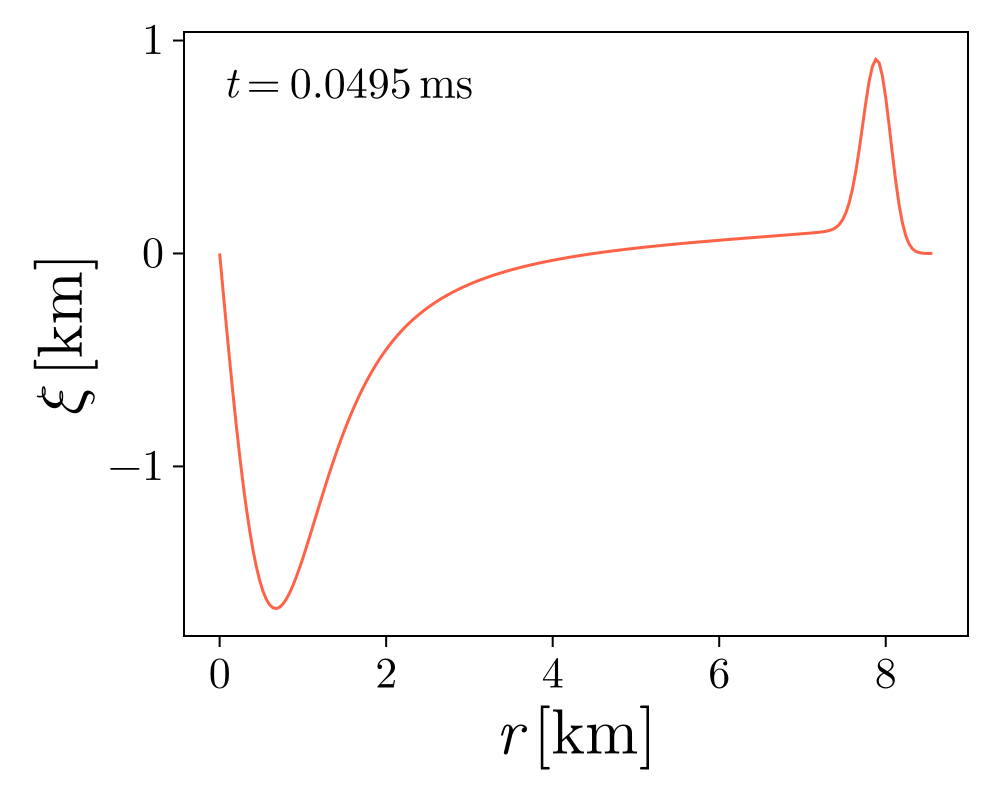

In [14]:
time = 0.05;
var = "xi";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";

plot_td_var(
    PF_star, h3, var, 0.0, cowling;
    desample_factor=1,
    annotate_time=true,
    xlabel = xlabel,
    ylabel = ylabel
);

plot_td_var(
    PF_star, h3, var, time, cowling;
    desample_factor=1,
    annotate_time=true,
    xlabel = xlabel,
    ylabel = ylabel
);

To monitor convergence, plot one-norm of independent residual for three different resolutions

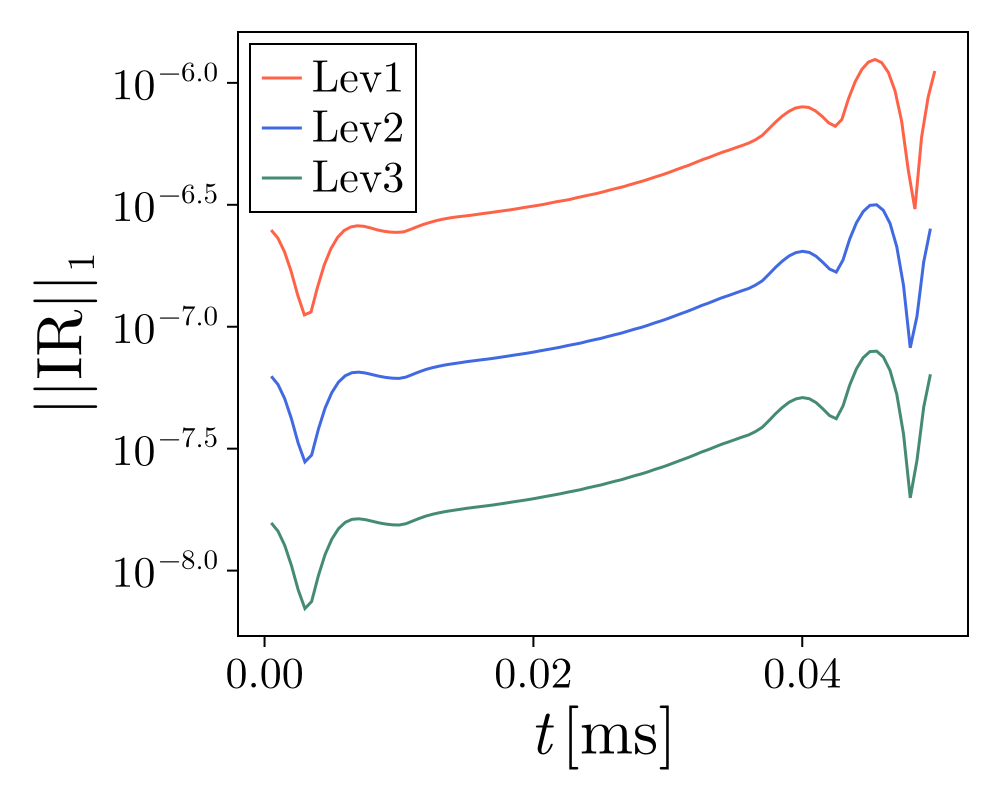

In [15]:
resolutions = [h1, h2, h3];
var = "IR";
xlabel = L"t\,[\mathrm{ms}]";
ylabel = L"||\mathrm{IR}||_1";
labels = ["Lev1", "Lev2", "Lev3"];
legend = true;
position = :lt;
plot_IR_one_norms(
    PF_star, resolutions, var, time, cowling;
    desample_factor=1,
    xlabel = xlabel,
    ylabel = ylabel,
    yscale = log10,
    labels = labels,
    legend = legend,
    position = position
);

Make basic animation of time evolution (saved to star.fig_path)

In [16]:
var = "xi";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
animate_td_var(
    PF_star, h3, var, cowling;
    desample_factor=1,
    stop_time=PF_star.T, # stop time of animation in ms
    animation_length=10.0, # length of animation in seconds
    framerate=10, # frames per second
    xlabel = xlabel,
    ylabel = ylabel,
    fix_ylims = false, # whether to fix y-limits of plot
)

"./Results/Figures/Time_domain_κ_700_n_0.8_εc_2.23e-03_ptol_7.55e-07_η_0.0e+00_ζ_0.0e+00_τε_0.0e+00_τP_0.0e+00_τQ_0.0e+00_L_1.0_KO_0.0_CFL_0.1_T_0.05_h_1.0e-02_xi.mp4"

## Eckart fluid

In [17]:
cowling = false;

In [18]:
@time time_integrate(Eckart_star, h1, cowling; print_progress = true);
@time time_integrate(Eckart_star, h2, cowling; print_progress = true);
@time time_integrate(Eckart_star, h3, cowling; print_progress = true);

Load solution and print keys

In [19]:
sol1 = load_td_solution(Eckart_star, h1, cowling);
keys(sol1["solution"])

11-element Vector{String}:
 "IR"
 "cs"
 "cs_prime"
 "m"
 "p"
 "r"
 "t"
 "xi"
 "xi_dot"
 "ε"
 "ν"

In [20]:
close(sol1)

Plot solution at fixed time

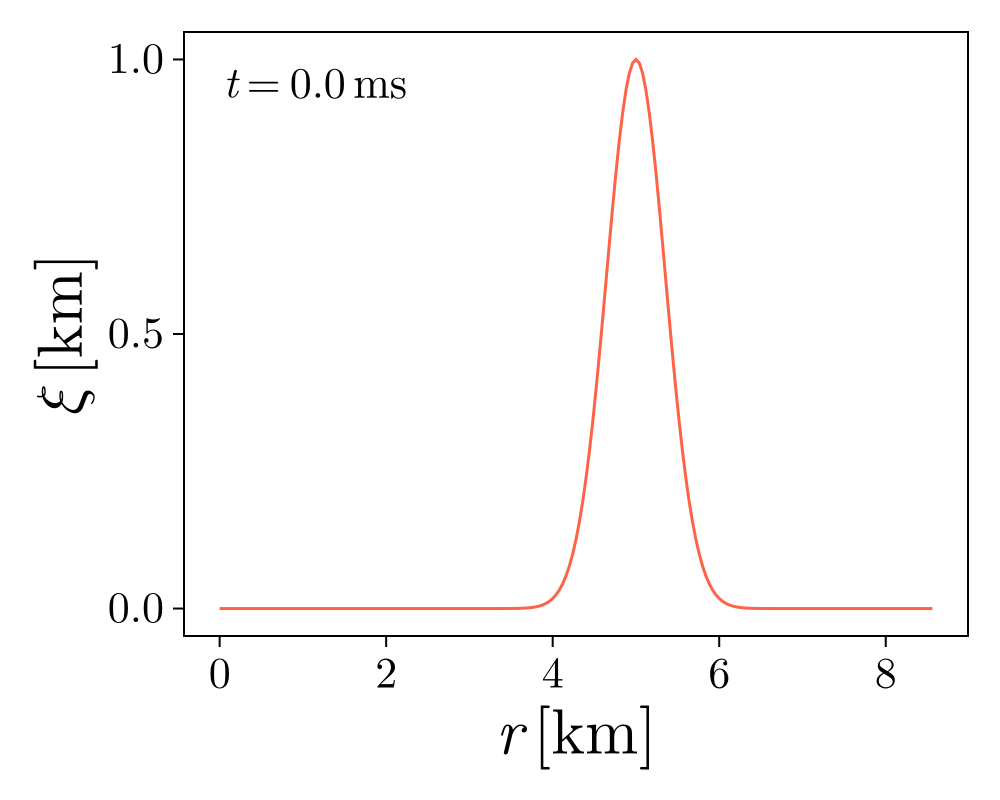

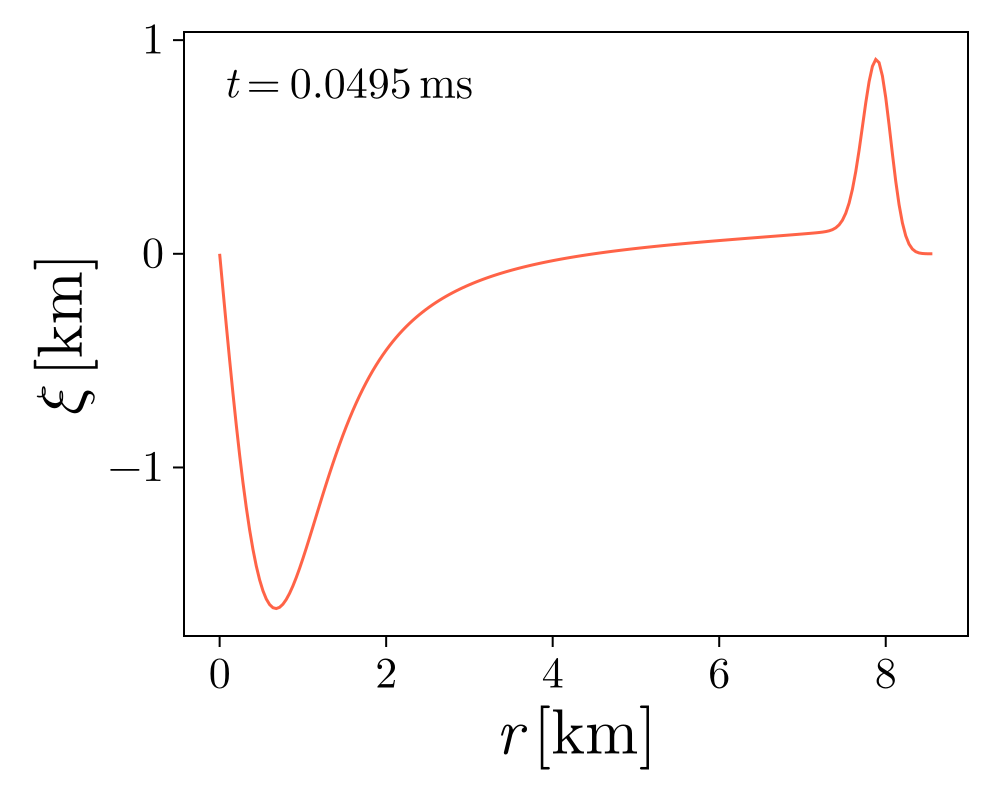

In [21]:
time = 0.05;
var = "xi";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";

plot_td_var(
    Eckart_star, h3, var, 0.0, cowling;
    desample_factor=1,
    annotate_time=true,
    xlabel = xlabel,
    ylabel = ylabel
);

plot_td_var(
    Eckart_star, h3, var, time, cowling;
    desample_factor=1,
    annotate_time=true,
    xlabel = xlabel,
    ylabel = ylabel
);

To monitor convergence, plot one-norm of independent residual for three different resolutions

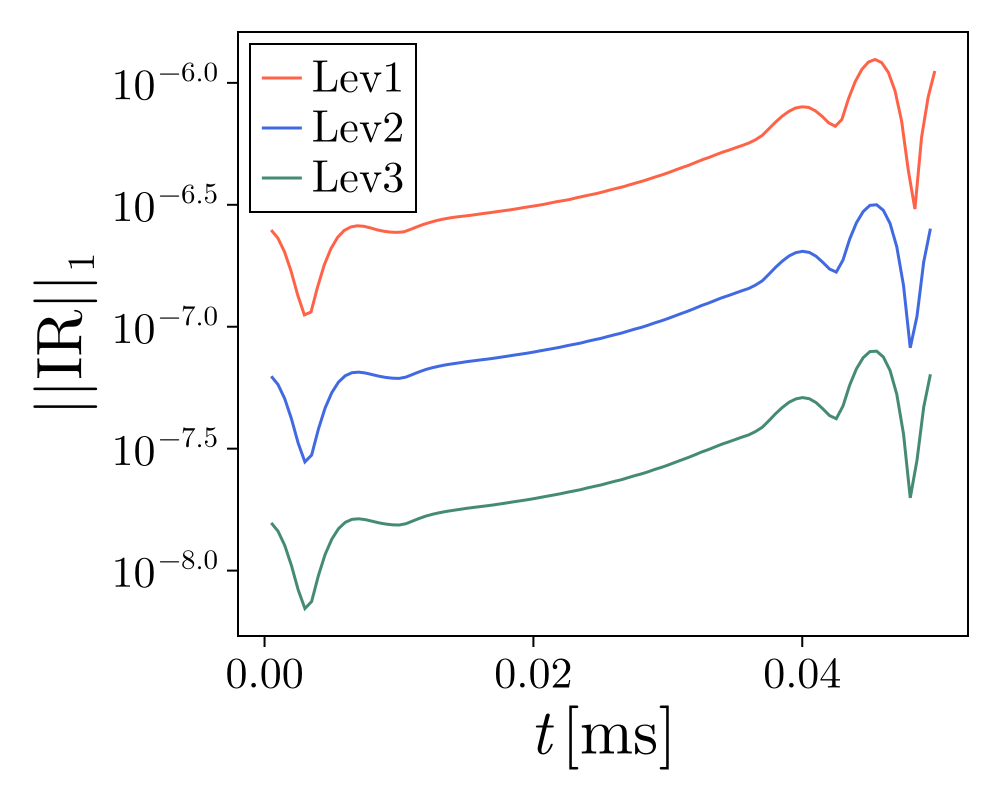

In [22]:
resolutions = [h1, h2, h3];
var = "IR";
xlabel = L"t\,[\mathrm{ms}]";
ylabel = L"||\mathrm{IR}||_1";
labels = ["Lev1", "Lev2", "Lev3"];
legend = true;
position = :lt;
plot_IR_one_norms(
    PF_star, resolutions, var, time, cowling;
    desample_factor=1,
    xlabel = xlabel,
    ylabel = ylabel,
    yscale = log10,
    labels = labels,
    legend = legend,
    position = position
);

Make basic animation of time evolution (saved to star.fig_path)

In [23]:
var = "xi";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
animate_td_var(
    PF_star, h3, var, cowling;
    desample_factor=1,
    stop_time=PF_star.T, # stop time of animation in ms
    animation_length=10.0, # length of animation in seconds
    framerate=10, # frames per second
    xlabel = xlabel,
    ylabel = ylabel,
    fix_ylims = false, # whether to fix y-limits of plot
)

"./Results/Figures/Time_domain_κ_700_n_0.8_εc_2.23e-03_ptol_7.55e-07_η_0.0e+00_ζ_0.0e+00_τε_0.0e+00_τP_0.0e+00_τQ_0.0e+00_L_1.0_KO_0.0_CFL_0.1_T_0.05_h_1.0e-02_xi.mp4"

## BDNK cowling

In [35]:
# check choice of frame in BDNK is causal
check_causal_frame(BDNK_star)

In [36]:
cowling = true;

In [37]:
@time time_integrate(BDNK_star, h1, cowling; print_progress = true);
@time time_integrate(BDNK_star, h2, cowling; print_progress = true);
@time time_integrate(BDNK_star, h3, cowling; print_progress = true);

Load solution and print keys

In [38]:
sol1 = load_td_solution(BDNK_star, h1, cowling);
keys(sol1["solution"])

20-element Vector{String}:
 "IR1"
 "IR2"
 "cs"
 "cs_prime"
 "cs_prime_prime"
 "deps"
 "deps_dot"
 "deps_dr"
 "du"
 "du_dot"
 "du_dr"
 "m"
 "p"
 "r"
 "t"
 "Λ0"
 "Λ1"
 "Λ2"
 "ε"
 "ν"

In [39]:
close(sol1)

Plot solution at fixed time

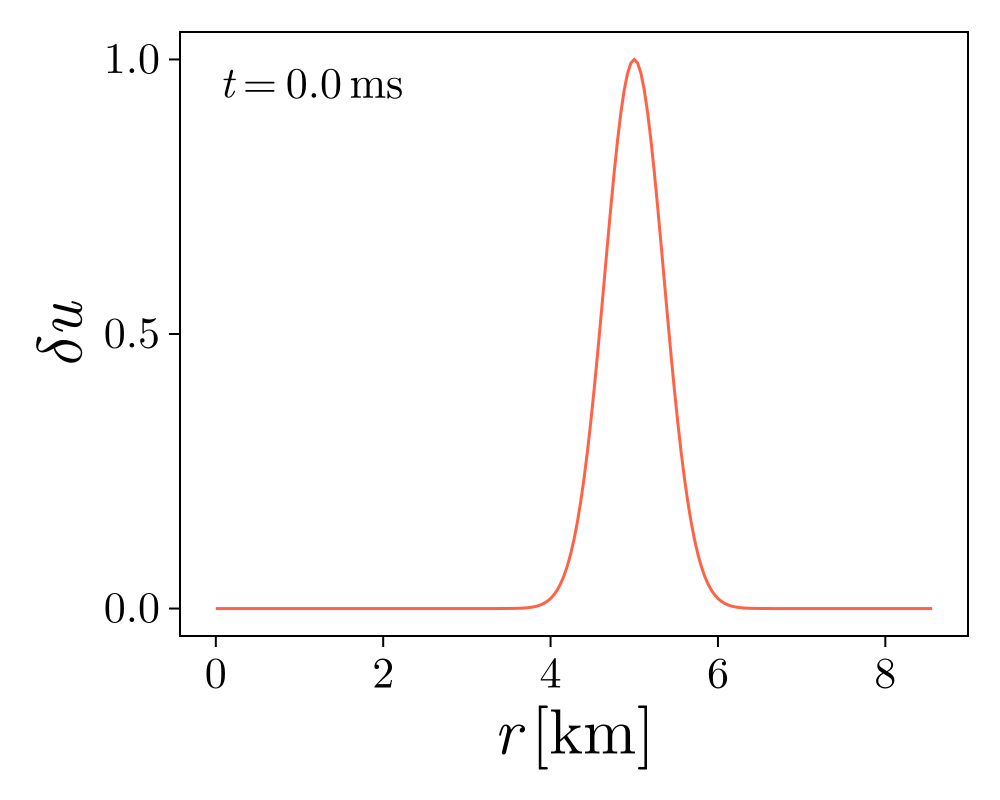

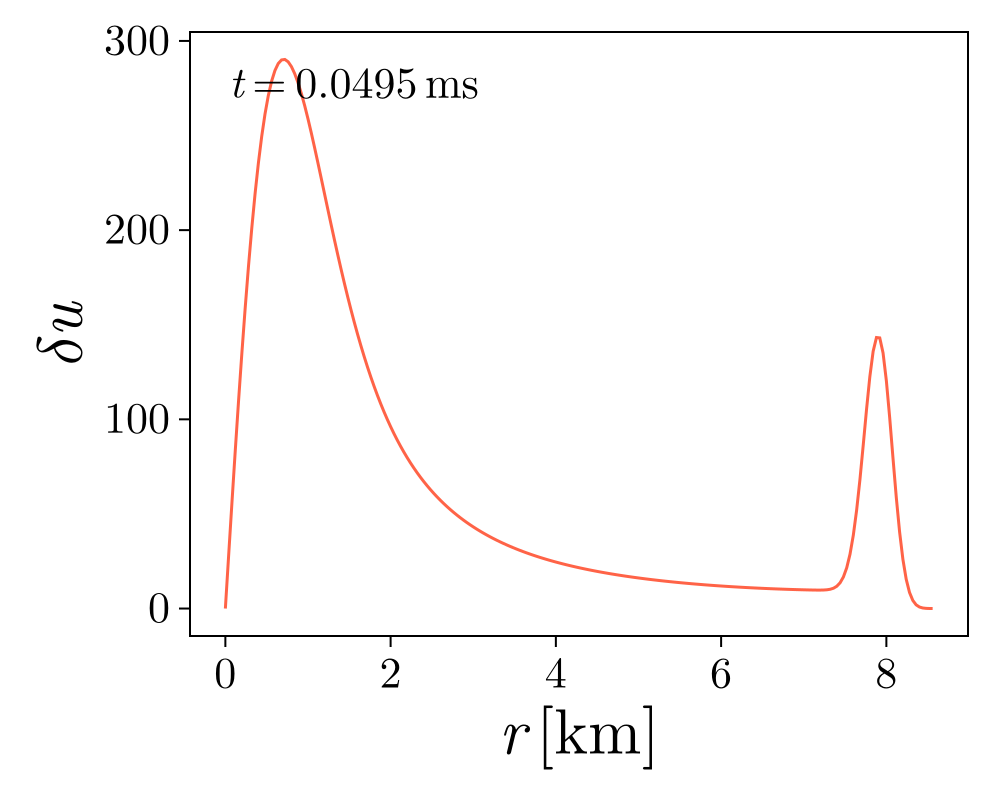

In [40]:
time = 0.05;
var = "du";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\delta{u}";

plot_td_var(
    BDNK_star, h3, var, 0.0, cowling;
    desample_factor=1,
    annotate_time=true,
    xlabel = xlabel,
    ylabel = ylabel
);

plot_td_var(
    BDNK_star, h3, var, time, cowling;
    desample_factor=1,
    annotate_time=true,
    xlabel = xlabel,
    ylabel = ylabel
);

To monitor convergence, plot one-norm of independent residual for three different resolutions

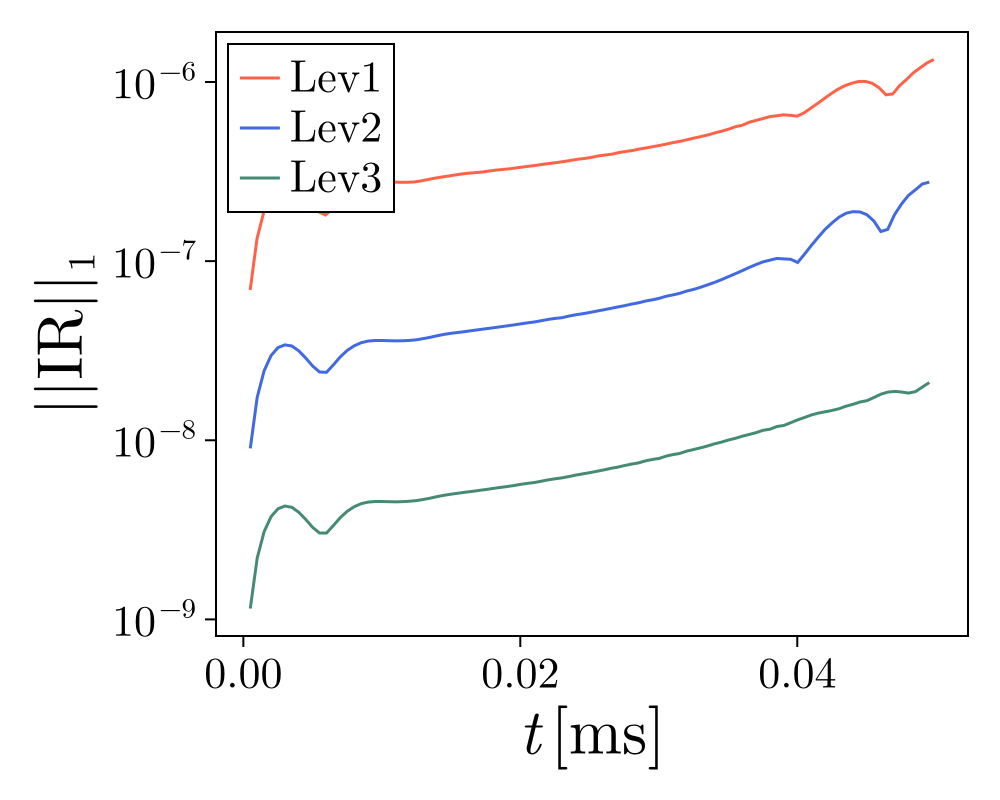

In [41]:
resolutions = [h1, h2, h3];
var = "IR1";
xlabel = L"t\,[\mathrm{ms}]";
ylabel = L"||\mathrm{IR}||_1";
labels = ["Lev1", "Lev2", "Lev3"];
legend = true;
position = :lt;
plot_IR_one_norms(
    BDNK_star, resolutions, var, time, cowling;
    desample_factor=1,
    xlabel = xlabel,
    ylabel = ylabel,
    yscale = log10,
    labels = labels,
    legend = legend,
    position = position
);

Make basic animation of time evolution (saved to star.fig_path)

In [42]:
var = "du";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\delta{u}";
animate_td_var(
    BDNK_star, h3, var, cowling;
    desample_factor=1,
    stop_time=BDNK_star.T, # stop time of animation in ms
    animation_length=10.0, # length of animation in seconds
    framerate=10, # frames per second
    xlabel = xlabel,
    ylabel = ylabel,
    fix_ylims = false, # whether to fix y-limits of plot
)

"./Results/Figures/Cowling_time_domain_κ_700_n_0.8_εc_2.23e-03_ptol_7.55e-07_η_1.0e-04_ζ_1.0e-04_τε_1.0e+01_τP_1.0e+00_τQ_5.0e+00_L_1.0_KO_0.1_CFL_0.1_T_0.05_h_1.0e-02_du.mp4"

## BDNK

In [28]:
# check choice of frame in BDNK is causal
check_causal_frame(BDNK_star)

In [51]:
cowling = false;

In [30]:
@time time_integrate(BDNK_star, h1, cowling; print_progress = true);
@time time_integrate(BDNK_star, h2, cowling; print_progress = true);
@time time_integrate(BDNK_star, h3, cowling; print_progress = true);

Load solution and print keys

In [43]:
sol1 = load_td_solution(BDNK_star, h1, cowling);
keys(sol1["solution"])

20-element Vector{String}:
 "IR1"
 "IR2"
 "cs"
 "cs_prime"
 "cs_prime_prime"
 "deps"
 "deps_dot"
 "deps_dr"
 "du"
 "du_dot"
 "du_dr"
 "m"
 "p"
 "r"
 "t"
 "Λ0"
 "Λ1"
 "Λ2"
 "ε"
 "ν"

In [44]:
close(sol1)

Plot characteristic speeds throughout star

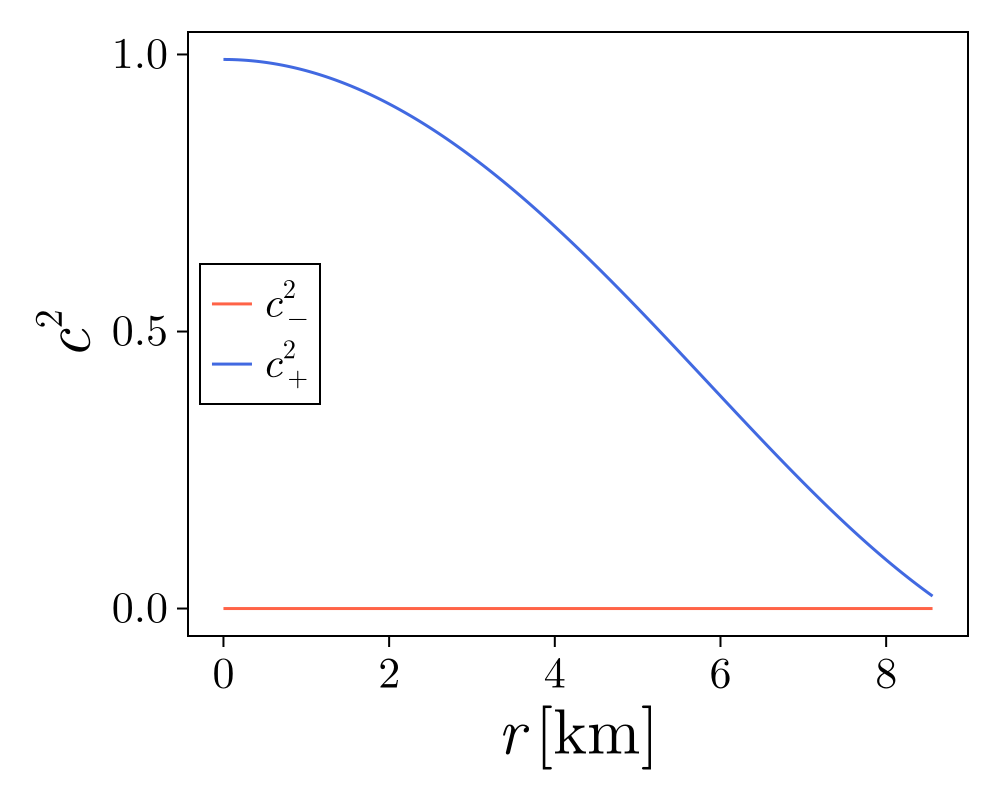

In [52]:
# plot characteristic speeds throughout star
plot_characteristic_speeds(BDNK_star, h3, cowling);

Plot convergence factor for initial data

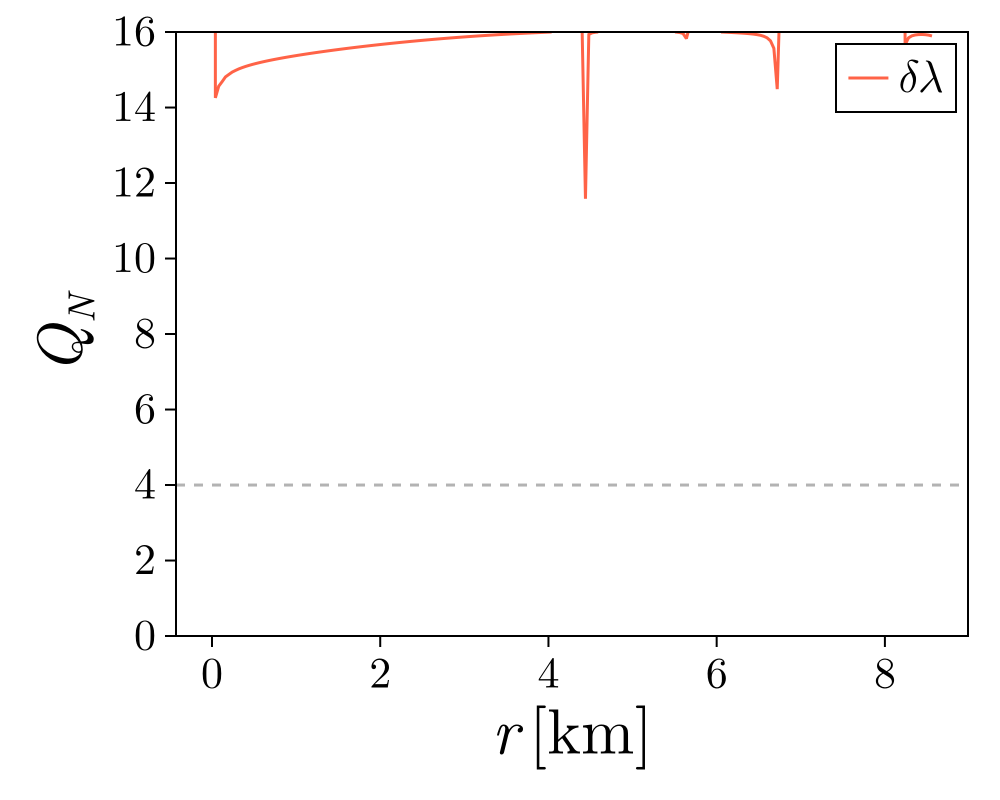

In [53]:
# plot convergence factor for initial data
plot_initial_data_convergence(BDNK_star, h3, cowling);

Plot solution at fixed time

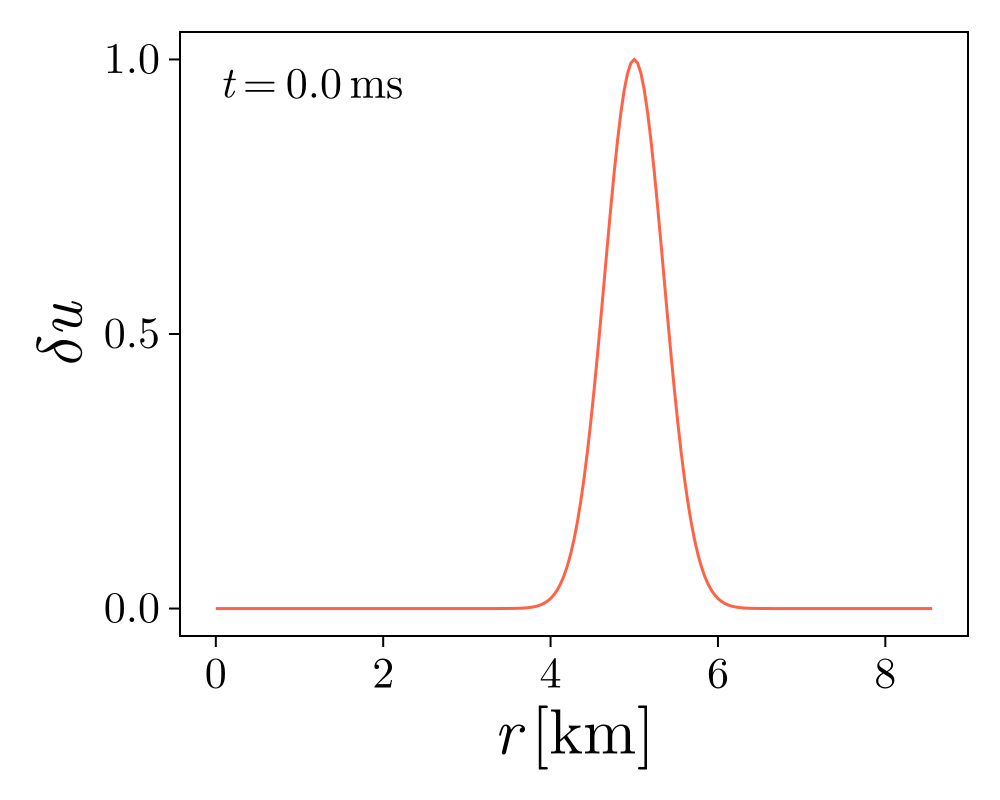

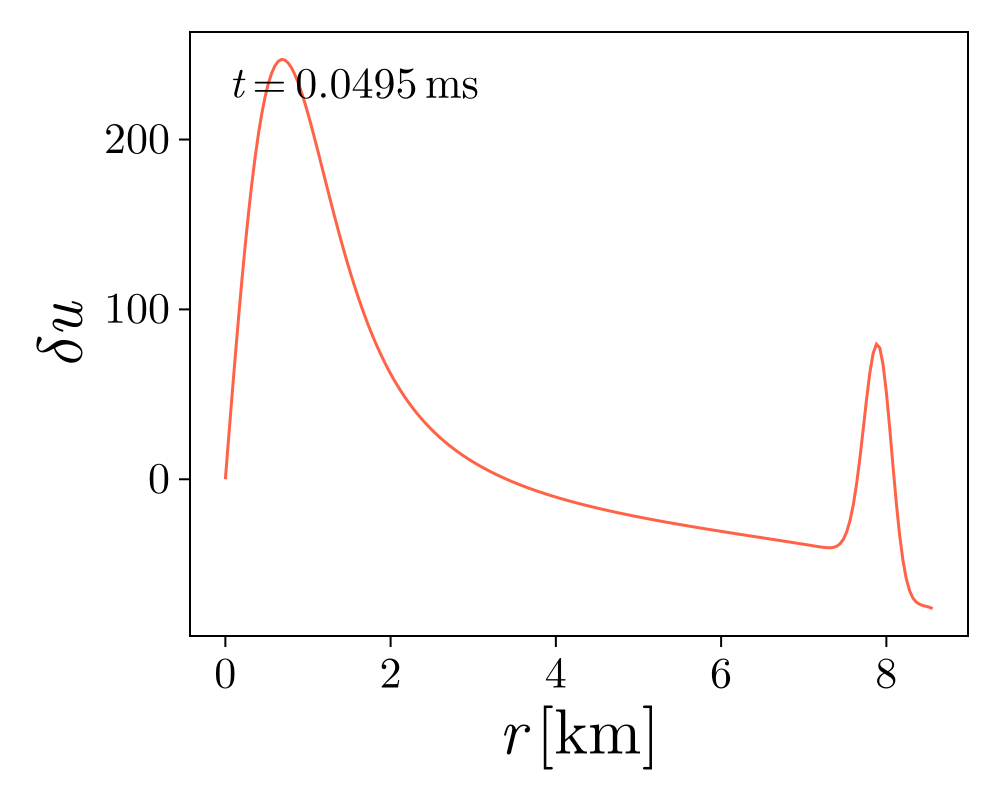

In [54]:
time = 0.05;
var = "du";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\delta{u}";

plot_td_var(
    BDNK_star, h3, var, 0.0, cowling;
    desample_factor=1,
    annotate_time=true,
    xlabel = xlabel,
    ylabel = ylabel
);

plot_td_var(
    BDNK_star, h3, var, time, cowling;
    desample_factor=1,
    annotate_time=true,
    xlabel = xlabel,
    ylabel = ylabel
);

To monitor convergence, plot one-norm of independent residual for three different resolutions

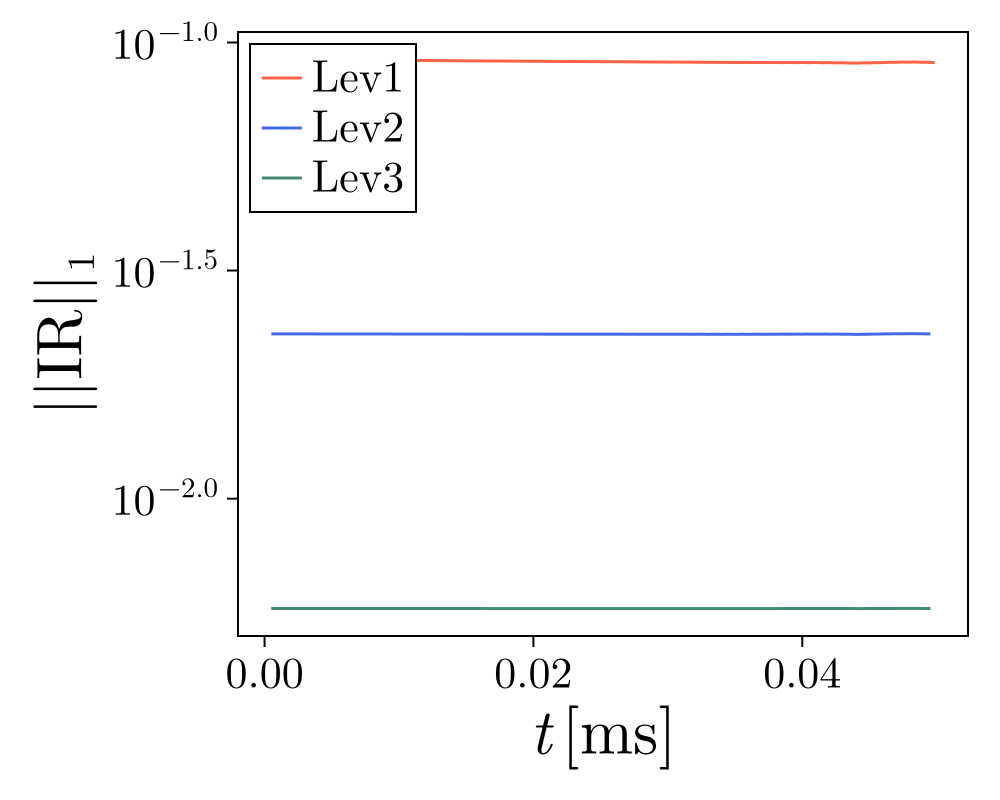

In [55]:
resolutions = [h1, h2, h3];
var = "Constrained_IR1";
xlabel = L"t\,[\mathrm{ms}]";
ylabel = L"||\mathrm{IR}||_1";
labels = ["Lev1", "Lev2", "Lev3"];
legend = true;
position = :lt;
plot_IR_one_norms(
    BDNK_star, resolutions, var, time, cowling;
    desample_factor=1,
    xlabel = xlabel,
    ylabel = ylabel,
    yscale = log10,
    labels = labels,
    legend = legend,
    position = position
);

Make basic animation of time evolution (saved to star.fig_path)

In [56]:
var = "du";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\delta{u}";
animate_td_var(
    BDNK_star, h3, var, cowling;
    desample_factor=1,
    stop_time=BDNK_star.T, # stop time of animation in ms
    animation_length=10.0, # length of animation in seconds
    framerate=10, # frames per second
    xlabel = xlabel,
    ylabel = ylabel,
    fix_ylims = false, # whether to fix y-limits of plot
)

"./Results/Figures/Time_domain_κ_700_n_0.8_εc_2.23e-03_ptol_7.55e-07_η_1.0e-04_ζ_1.0e-04_τε_1.0e+01_τP_1.0e+00_τQ_5.0e+00_L_1.0_KO_0.1_CFL_0.1_T_0.05_h_1.0e-02_du.mp4"